In [57]:
from random import random

import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
import random as rnd

In [58]:
file_name = "tf_intro"
rand_file_suffix = file_name +"_"+ str(rnd.randint(0,1000))
observations = 1000
xs = np.random.uniform(low=-10, high=10, size=(observations,1))
zs = np.random.uniform(low=-10, high=10, size=(observations,1))
generated_inputs = np.column_stack((xs, zs))
noise = np.random.uniform(low=-1, high=1, size=(observations,1))
generated_targets = 2*xs - 3*zs + 5 + noise
np.savez(rand_file_suffix, inputs=generated_inputs, targets=generated_targets)

In [59]:
modified_file_name = rand_file_suffix +".npz"
training_data = np.load(modified_file_name)

In [60]:
input_size = 2
output_size = 1
model = tf.keras.Sequential([
    tf.keras.layers.Dense(
                    output_size,
                    kernel_initializer=tf.random_uniform_initializer(minval=-0.1, maxval=0.1),
                    bias_initializer=tf.random_uniform_initializer(minval=-0.1, maxval=0.1)
                          )
])
#model.compile(optimizer='sgd',loss='mean_squared_error')
# custom_optimizer = tf.keras.optimizers.Adam(learning_rate=0.02)
custom_optimizer = tf.keras.optimizers.SGD(learning_rate=0.02)
model.compile(optimizer=custom_optimizer,loss='mean_squared_error')
model.fit(training_data['inputs'], training_data['targets'],epochs=100, verbose=2)
model


Epoch 1/100
32/32 - 0s - 13ms/step - loss: 33.5745
Epoch 2/100
32/32 - 0s - 5ms/step - loss: 1.1312
Epoch 3/100
32/32 - 0s - 2ms/step - loss: 0.4105
Epoch 4/100
32/32 - 0s - 3ms/step - loss: 0.3857
Epoch 5/100
32/32 - 0s - 3ms/step - loss: 0.3633
Epoch 6/100
32/32 - 0s - 6ms/step - loss: 0.3737
Epoch 7/100
32/32 - 0s - 3ms/step - loss: 0.3874
Epoch 8/100
32/32 - 0s - 2ms/step - loss: 0.3924
Epoch 9/100
32/32 - 0s - 3ms/step - loss: 0.3814
Epoch 10/100
32/32 - 0s - 2ms/step - loss: 0.3579
Epoch 11/100
32/32 - 0s - 3ms/step - loss: 0.3782
Epoch 12/100
32/32 - 0s - 3ms/step - loss: 0.4050
Epoch 13/100
32/32 - 0s - 3ms/step - loss: 0.3807
Epoch 14/100
32/32 - 0s - 2ms/step - loss: 0.3769
Epoch 15/100
32/32 - 0s - 2ms/step - loss: 0.3719
Epoch 16/100
32/32 - 0s - 2ms/step - loss: 0.3766
Epoch 17/100
32/32 - 0s - 3ms/step - loss: 0.3637
Epoch 18/100
32/32 - 0s - 2ms/step - loss: 0.3634
Epoch 19/100
32/32 - 0s - 3ms/step - loss: 0.3949
Epoch 20/100
32/32 - 0s - 5ms/step - loss: 0.3764
Epoch 2

<Sequential name=sequential_6, built=True>

In [61]:
weights = model.layers[0].get_weights()[0]
weights

array([[ 2.0108204],
       [-2.9971278]], dtype=float32)

In [62]:
bias = model.layers[0].get_weights()[1]
bias

array([5.0225644], dtype=float32)

# Extract the outputs and predict outputs

In [63]:
predicted_response = model.predict_on_batch(training_data['inputs']).round(1)
target_list = training_data['targets'].round(1)

In [64]:
for val in range(0, len(training_data['targets'])):
    print(target_list[val], "==>", predicted_response[val])


[36.8] ==> [36.5]
[-2.2] ==> [-2.5]
[-12.6] ==> [-12.2]
[15.4] ==> [15.6]
[-15.5] ==> [-14.9]
[9.9] ==> [10.5]
[27.6] ==> [28.]
[-12.] ==> [-12.6]
[14.5] ==> [14.4]
[26.] ==> [26.7]
[40.4] ==> [40.]
[6.7] ==> [5.9]
[37.4] ==> [36.9]
[-21.7] ==> [-21.4]
[0.3] ==> [-0.4]
[26.7] ==> [27.6]
[12.5] ==> [11.9]
[5.2] ==> [4.4]
[29.6] ==> [30.4]
[19.9] ==> [20.8]
[-20.2] ==> [-20.9]
[49.7] ==> [50.7]
[11.3] ==> [10.8]
[-2.2] ==> [-2.7]
[3.2] ==> [2.5]
[-11.5] ==> [-11.3]
[-1.3] ==> [-2.2]
[-17.] ==> [-16.1]
[-9.] ==> [-8.4]
[5.7] ==> [5.6]
[6.4] ==> [6.5]
[2.1] ==> [2.2]
[30.8] ==> [30.9]
[8.6] ==> [8.2]
[39.3] ==> [39.3]
[13.5] ==> [13.9]
[31.9] ==> [32.5]
[-19.4] ==> [-20.2]
[-25.9] ==> [-25.1]
[21.8] ==> [22.]
[-6.3] ==> [-5.4]
[25.3] ==> [25.7]
[12.6] ==> [11.7]
[5.6] ==> [6.5]
[15.2] ==> [14.4]
[-38.5] ==> [-38.4]
[-17.5] ==> [-17.2]
[-19.8] ==> [-20.]
[0.4] ==> [-0.2]
[-6.8] ==> [-6.]
[37.9] ==> [37.2]
[39.] ==> [38.2]
[20.] ==> [20.8]
[-16.] ==> [-16.9]
[12.4] ==> [12.9]
[-27.1] ==> [-2

# Plotting data

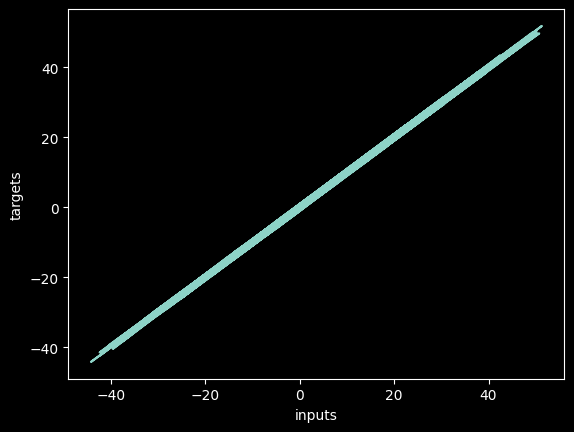

In [65]:
plt.plot(np.squeeze(model.predict_on_batch(training_data['inputs'])) , np.squeeze(training_data['targets']))
plt.xlabel("inputs")
plt.ylabel("targets")
plt.show()